### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qu
import itertools as it
from scipy import linalg, optimize
import time

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [3]:
def create_Hus(g10, g21, vels, γ10, γ21, f01=385e6, f02=625e6):
    """
    Function for creating a list of 3x3 Hamiltonians.  Note that the only detuning is due to the Doppler affect
    :param g10:        the coupling strength between |0> and |1>
    :param g21:        the coupling strength between |1> and |2>
    :param vels:       array of velocities for the atoms for calculating Doppler shifts
    :param f01:        frequency of laser coupling |0> and |1> in MHz
    :param f02:        frequency of laser coupling |1> and |2> in MHz
    :returns:          a list of Hamiltonians
    """
    # Calculate the detunings for each atom
    Δ1s = f01 / 3e8 * vels
    Δ2s = f02 / 3e8 * vels

    # Now create the Hamiltonians
    Hs = [qu.Qobj(np.array([[0, g10, 0],
                            [g10, -_[0]-1j*γ10, g21],
                            [0, g21, -_[0]-_[1]-1j*γ21]])) for _ in zip(Δ1s, Δ2s)]

    return Hs

In [4]:
def create_H0s(g10, g21, g32, vels, γ10, γ21, γ32, κ, f01=385e6, f02=625e6):
    """
    Function for creating a list of 4x4 Hamiltonians.  Note that the only detuning is due to the Doppler affect
    :param g10:        the coupling strength between |0> and |1>
    :param g21:        the coupling strength between |1> and |2>
    :param vels:       array of velocities for the atoms for calculating Doppler shifts
    :param f01:        frequency of laser coupling |0> and |1> in MHz
    :param f02:        frequency of laser coupling |1> and |2> in MHz
    :returns:          a list of Hamiltonians
    """
    # Calculate the detunings for each atom
    Δ1s = f01 / 3e8 * vels
    Δ2s = f02 / 3e8 * vels

    # Now create the Hamiltonians
    Hs = [qu.Qobj(np.array([[-1j*κ, g10, 0, 0],
                            [g10, -_[0]-1j*γ10-1j*κ, g21, 0],
                            [0, g21, -_[0]-_[1]-1j*γ21-1j*κ, g32],
                            [0, 0, g32, -_[0] -_[1] -1j*γ32]])) for _ in zip(Δ1s, Δ2s)]

    return Hs

### Testing General 2 atom Perturbation Theory

In [5]:
# Define our base Hamiltonians
H0 = qu.Qobj([[0, 50],
              [50, 0]])
H1 = qu.Qobj([[5, 50],
              [50, 10]])

In [6]:
# Get the total Hamiltonian
H_tot = qu.tensor(H0, qu.qeye(2)) + qu.tensor(qu.qeye(2), H1)
H_tot

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 5. 50. 50.  0.]
 [50. 10.  0. 50.]
 [50.  0.  5. 50.]
 [ 0. 50. 50. 10.]]

In [7]:
# Get the eigenstates
H0_eigs = H0.eigenstates()
H1_eigs = H1.eigenstates()
H_tot_eigs = H_tot.eigenstates()

In [8]:
# Now define the perturbation matrix
V0 = qu.Qobj([[3, 4],
              [4, 3]])
V_tot = qu.tensor(V0, qu.qeye(2)) + qu.tensor(qu.qeye(2), V0)

In [9]:
# Now perturb the matrices using a small parameter
λ = 1e-3
H0_λ = H0 + λ * V0
H1_λ = H1 + λ * V0
H_tot_λ = H_tot + λ * V_tot

In [10]:
# Get the exact eigenvalues and eigenvectors of the perturbed matrices
ex_H0_λ_eigs = H0_λ.eigenstates()
ex_H1_λ_eigs = H1_λ.eigenstates()
ex_H_tot_λ_eigs = H_tot_λ.eigenstates()

In [11]:
# Now calculate the results from perturbation theory to O(λ)
calc_H0_λ_energies = np.array([H0_eigs[0][i] + λ * H0_eigs[1][i].dag() * V0 * H0_eigs[1][i] for i in range(2)])
print("H0 Results")
print("Exact: ", ex_H0_λ_eigs[0])
print("Calc: ", calc_H0_λ_energies)

calc_H1_λ_energies = np.array([H1_eigs[0][i] + λ * H1_eigs[1][i].dag() * V0 * H1_eigs[1][i] for i in range(2)])
print("\nH1 Results")
print("Exact: ", ex_H1_λ_eigs[0])
print("Calc: ", calc_H1_λ_energies)

calc_H_tot_λ_energies = np.array([H_tot_eigs[0][i] + λ * H_tot_eigs[1][i].dag() * V_tot * H_tot_eigs[1][i] for i in range(4)])
print("\nH_tot Results")
print("Exact: ", ex_H_tot_λ_eigs[0])
print("Calc: ", calc_H_tot_λ_energies)

H0 Results
Exact:  [-50.001  50.007]
Calc:  [-50.001+0.j  50.007+0.j]

H1 Results
Exact:  [-42.563456  57.569456]
Calc:  [-42.563456+0.j  57.569456+0.j]

H_tot Results
Exact:  [-92.564456   7.443544   7.568456 107.576456]
Calc:  [-92.564456+0.j   7.443544+0.j   7.568456+0.j 107.576456+0.j]


In [12]:
# Now let's perturb one of the eigenstates
calc_H0_λ_state0 = H0_eigs[1][0] 
calc_H0_λ_state0 -= λ * np.sum([H0_eigs[1][i].dag() * V0 * H0_eigs[1][0] * H0_eigs[1][i] / (H0_eigs[0][i] - H0_eigs[0][0]) for i in range(1,2)])
print("H0 Eigenstates")
print("Exact: ", ex_H0_λ_eigs[1][0])
print("Calc: ", calc_H0_λ_state0)

calc_H1_λ_state0 = H1_eigs[1][0]
calc_H1_λ_state0 -= λ * np.sum([H1_eigs[1][i].dag() * V0 * H1_eigs[1][0] * H1_eigs[1][i] / (H1_eigs[0][i] - H1_eigs[0][0]) for i in range(1,2)])
print("\nH1 Eigenstates")
print("Exact: ", ex_H1_λ_eigs[1][0])
print("Calc: ", calc_H1_λ_state0)

calc_Ht_λ_state0 = H_tot_eigs[1][0]
calc_Ht_λ_state0 -= λ * np.sum([H_tot_eigs[1][i].dag() * V_tot * H_tot_eigs[1][0] * H_tot_eigs[1][i] / (H_tot_eigs[0][i] - H_tot_eigs[0][0]) for i in range(1,2)])
print("\nH_tot Eigenstates")
print("Exact: ", ex_H_tot_λ_eigs[1][0])
print("Calc: ", calc_Ht_λ_state0)

H0 Eigenstates
Exact:  Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70710678]
 [ 0.70710678]]
Calc:  Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70710678]
 [ 0.70710678]]

H1 Eigenstates
Exact:  Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.72454594]
 [ 0.68922651]]
Calc:  Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.72454594]
 [ 0.68922651]]

H_tot Eigenstates
Exact:  Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.51233135]
 [-0.48735674]
 [-0.51233135]
 [ 0.48735674]]
Calc:  Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.51233232]
 [-0.48735572]
 [-0.51233232]
 [ 0.48735572]]


In [13]:
# Now let's verify that the tensor product of the two perturbed states yields the perturbed total state
print("Perturbed H_tot |0> from tensor product: ", qu.tensor(calc_H0_λ_state0, calc_H1_λ_state0))
print("Exact total perturbed H_tot |0>: ", ex_H_tot_λ_eigs[1][0])

Perturbed H_tot |0> from tensor product:  Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.51233135]
 [-0.48735674]
 [-0.51233135]
 [ 0.48735674]]
Exact total perturbed H_tot |0>:  Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.51233135]
 [-0.48735674]
 [-0.51233135]
 [ 0.48735674]]


In [14]:
# Now let's get all the perturbed eigenstates
calc_H0_λ_states = []
calc_H1_λ_states = []
calc_Ht_λ_states = []
for i in range(2):
    temp_list_0 = []
    temp_list_1 = []
    temp_list_t = []
    for j in range(2):
        if j == i:
            continue
        else:
            temp_list_0.append(H0_eigs[1][j].dag() * V0 * H0_eigs[1][i] * H0_eigs[1][j] / (H0_eigs[0][j] - H0_eigs[0][i]))
            temp_list_1.append(H1_eigs[1][j].dag() * V0 * H1_eigs[1][i] * H1_eigs[1][j] / (H1_eigs[0][j] - H1_eigs[0][i]))
            temp_list_t.append(H_tot_eigs[1][j].dag() * V_tot * H_tot_eigs[1][i] * H_tot_eigs[1][j] / (H_tot_eigs[0][j] - H_tot_eigs[0][i]))
    calc_H0_λ_states.append(H0_eigs[1][i] - λ * np.sum(temp_list_0))
    calc_H1_λ_states.append(H1_eigs[1][i] - λ * np.sum(temp_list_1))
    calc_Ht_λ_states.append(H_tot_eigs[1][i] - λ * np.sum(temp_list_t))

calc_H0_λ_states = np.array(calc_H0_λ_states)
calc_H1_λ_states = np.array(calc_H1_λ_states)
calc_Ht_λ_states = np.array(calc_Ht_λ_states)

In [15]:
# Now verify
for i in range(2):
    print("H0 state " + str(i) + " match? ", np.allclose(calc_H0_λ_states[i].full(), H0_eigs[1][i].full()))
    print("H1 state " + str(i) + " match? ", np.allclose(calc_H1_λ_states[i].full(), H1_eigs[1][i].full()))
    print("Ht state " + str(i) + " match? ", np.allclose(calc_Ht_λ_states[i].full(), H_tot_eigs[1][i].full()))

H0 state 0 match?  True
H1 state 0 match?  True
Ht state 0 match?  True
H0 state 1 match?  True
H1 state 1 match?  True
Ht state 1 match?  True


In [16]:
# Check that the tensor products of the the perturbed H0 and H1 states match the exact total perturbed states
tens_list = []
for i in range(2):
    for j in range(2):
        tens_list.append(qu.tensor(calc_H0_λ_states[i], calc_H1_λ_states[j]))

In [17]:
for i in range(4):
    print(np.allclose(tens_list[0].full(), ex_H_tot_λ_eigs[1][0].full()))

True
True
True
True


### Calculated vs Exact Eigenstates for 1 atom in our system
What about something more like what we have?  From what I understand, we have $H_t = H_u \oplus H_p$, so the eigenstates of $H_u$ and $H_p$ are eigenstates of $H_t$.  The eigenstates of $H_u$ are a linear combination of $\{|0,0\rangle, |0,1\rangle, |0,2\rangle\}$ and the eigenstates of $H_p$ are a linear combination of $\{|1,0\rangle, |1,1\rangle, |1,2\rangle, |0,3\rangle\}$.  The effect of the pertubation is $V=\sum_{j=0}^2 |1,j\rangle\langle 0,j| + |0,j\rangle\langle 1,j|$.  From my math, this means that the first order correction to an eigenstate of $H_u$ should be $|(\phi_j^0)^{(1)}\rangle=-\sum_{k=0}^3\frac{\langle(\chi_k^1)^{(0)}|V|(\phi_j^0)^{(0)}}{E_k^1-E_j^0}|(\phi_k^1)^{(0)}\rangle$, where $\phi_m^0$ denotes the $m^{th}$ eigenstate of $H_u$ and $\phi_m^1$ denotes the $m^{th}$ eigenstate of $H_p$.  The bras labelled with $\chi$ are the counterparts to $\phi$ so that we have a biorthogonal basis.  This is necessary because the Hamiltonians are not Hermitian in this case.

In [18]:
# Define parameters
g10 = 50
g21 = 10
g32 = 50
κ = 1
γ1 = 1
γ2 = 0.05
γ3 = 0.05

In [19]:
# Define H_u and H_p
Hu = np.array([[0, g10, 0],
              [g10, -1j*γ1, g21],
              [0, g21, -1j*γ2]])
Hp = np.array([[-1j*κ, g10, 0, 0],
              [g10, -1j*κ -1j*γ1, g21, 0],
              [0, g21, -1j*κ -1j*γ2, g32],
              [0, 0, g32, -1j*γ3]])

In [20]:
# Get Ht from the direct sum
Ht = linalg.block_diag(Hu, Hp)

In [21]:
# Turn all the matrices into Qobj for ease of use
Hu = qu.Qobj(Hu)
Hp = qu.Qobj(Hp)
Ht = qu.Qobj(Ht)

In [22]:
Ht

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.+0.j   50.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [50.+0.j    0.-1.j   10.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j   10.+0.j    0.-0.05j  0.+0.j    0.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.-1.j   50.+0.j    0.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j   50.+0.j    0.-2.j   10.+0.j    0.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j   10.+0.j    0.-1.05j 50.+0.j  ]
 [ 0.+0.j    0.+0.j    0.+0.j    0.+0.j    0.+0.j   50.+0.j    0.-0.05j]]

In [23]:
# Get the unperturbed eigenstates
Hu_eigs = Hu.eigenstates()
Hp_eigs = Hp.eigenstates()
Ht_eigs = Ht.eigenstates()

In [24]:
# Get the left eigenstates
Hu_left_eigs = Hu.dag().eigenstates()
Hp_left_eigs = Hp.dag().eigenstates()
Ht_left_eigs = Ht.dag().eigenstates()

In [25]:
Hu_eigs[0]

array([-5.09877521e+01-0.50096156j, -1.32569496e-16-0.04807689j,
        5.09877521e+01-0.50096156j])

In [26]:
Hp_eigs[0]

array([-55.2245079 -1.07497807j, -45.26927736-0.97502193j,
        45.26927736-0.97502193j,  55.2245079 -1.07497807j])

In [27]:
Ht_eigs[0]

array([-5.52245079e+01-1.07497807j, -5.09877521e+01-0.50096156j,
       -4.52692774e+01-0.97502193j, -1.32569496e-16-0.04807689j,
        4.52692774e+01-0.97502193j,  5.09877521e+01-0.50096156j,
        5.52245079e+01-1.07497807j])

In [28]:
Ht_left_eigs[0]

array([-5.52245079e+01+1.07497807j, -5.09877521e+01+0.50096156j,
       -4.52692774e+01+0.97502193j, -1.32569496e-16+0.04807689j,
        4.52692774e+01+0.97502193j,  5.09877521e+01+0.50096156j,
        5.52245079e+01+1.07497807j])

In [29]:
V = np.zeros((7,7), dtype=complex)
V[0][3] = 1
V[1][4] = 1
V[2][5] = 1
V[3][0] = 1
V[4][1] = 1
V[5][2] = 1
V = qu.Qobj(V)

In [30]:
# Now we want to get the perturbed system
H_pert = Ht + λ * V
H_pert_eigs = H_pert.eigenstates()

In [31]:
# Calculate the perturbation of Hu using our formula
calc_pert_eigs = []
for j in range(1, 6, 2):
    temp_list = []
    for i in range(7):
        if i == j:
            continue
        else:
            temp_list.append((Ht_left_eigs[1][i].dag() * V * Ht_eigs[1][j]) / (Ht_eigs[0][i] - Ht_eigs[0][j]) * Ht_eigs[1][i])
    calc_pert_eigs.append(Ht_eigs[1][j] - λ * np.sum(temp_list))

#### 1st Eigenstate (Hu 0)

In [32]:
print("Exact: \n", H_pert_eigs[1][1])

Exact: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-6.93341522e-01+6.81217418e-03j]
 [ 7.07106765e-01+0.00000000e+00j]
 [-1.38670840e-01+1.22647512e-03j]
 [-2.80524789e-05+3.11856680e-06j]
 [ 4.24423615e-05-3.59640300e-06j]
 [-1.46313228e-04+9.10668961e-06j]
 [ 1.43388598e-04-1.01984733e-05j]]


In [33]:
print("Calc: \n", calc_pert_eigs[0])

Calc: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-6.93341537e-01+6.81217430e-03j]
 [ 7.07106781e-01+0.00000000e+00j]
 [-1.38670846e-01+1.22647533e-03j]
 [-2.73746917e-05+6.88064269e-06j]
 [ 4.15997382e-05-8.62243545e-06j]
 [-1.44131419e-04+2.19219854e-05j]
 [ 1.41155539e-04-2.24968342e-05j]]


In [34]:
# Get the result from the inversion approach
temp = Ht_eigs[0][1] * qu.qeye(7) - Ht
inv_app = Ht_eigs[1][1] + λ * temp.inv() * V * Ht_eigs[1][1]
print("Inv: \n", inv_app)

Inv: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-6.93341537e-01+6.81217430e-03j]
 [ 7.07106781e-01+0.00000000e+00j]
 [-1.38670846e-01+1.22647533e-03j]
 [-2.80524818e-05+3.11856729e-06j]
 [ 4.24423649e-05-3.59640354e-06j]
 [-1.46313232e-04+9.10669046e-06j]
 [ 1.43388602e-04-1.01984741e-05j]]


In [35]:
# Print the norm differences
print("Inverse Approach: ", linalg.norm(H_pert_eigs[1][1].full() - inv_app.full()))
print("Gen. Pert. Approach: ", linalg.norm(H_pert_eigs[1][1].full() - calc_pert_eigs[0].full()))

Inverse Approach:  2.2546628677969238e-08
Gen. Pert. Approach:  1.912622461470858e-05


#### 2nd Eigenstate (Hu 1)

In [36]:
print("Exact: \n", H_pert_eigs[1][3])

Exact: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-1.96119584e-01-6.93889390e-18j]
 [ 8.35479418e-17+1.88576387e-04j]
 [ 9.80579968e-01+0.00000000e+00j]
 [-3.49453418e-17+1.49398465e-07j]
 [ 3.91954736e-06+4.58759662e-17j]
 [ 2.70615727e-17-7.84455883e-10j]
 [-2.03954931e-05-4.84471082e-17j]]


In [37]:
print("Calc: \n", calc_pert_eigs[1])

Calc: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-1.96119584e-01+1.38777878e-17j]
 [ 2.71050543e-18+1.88576390e-04j]
 [ 9.80579968e-01+0.00000000e+00j]
 [ 1.73472348e-21+4.51430187e-07j]
 [ 3.90052731e-06+3.79470760e-21j]
 [-1.82145965e-20-1.65241248e-06j]
 [-2.01974439e-05-4.98732999e-21j]]


In [38]:
# Get the result from the inversion approach
temp = Ht_eigs[0][3] * qu.qeye(7) - Ht
inv_app = Ht_eigs[1][3] + λ * temp.inv() * V * Ht_eigs[1][3]
print("Inv: \n", inv_app)

Inv: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-1.96119584e-01+1.38777878e-17j]
 [ 2.71050543e-18+1.88576390e-04j]
 [ 9.80579968e-01+0.00000000e+00j]
 [-6.45184343e-23+1.49398465e-07j]
 [ 3.91954736e-06-2.79180202e-22j]
 [ 5.40742155e-23-7.84455851e-10j]
 [-2.03954931e-05+5.69216843e-23j]]


In [39]:
# Print the norm differences
print("Inverse Approach: ", linalg.norm(H_pert_eigs[1][3].full() - inv_app.full()))
print("Gen. Pert. Approach: ", linalg.norm(H_pert_eigs[1][3].full() - calc_pert_eigs[1].full()))

Inverse Approach:  2.2896883509299422e-10
Gen. Pert. Approach:  1.6907642074993107e-06


#### 3rd Eigenstate (Hu 2)

In [40]:
print("Exact: \n", H_pert_eigs[1][5])

Exact: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[ 6.93341522e-01+6.81217418e-03j]
 [ 7.07106765e-01+0.00000000e+00j]
 [ 1.38670840e-01+1.22647512e-03j]
 [-2.80524789e-05-3.11856680e-06j]
 [-4.24423615e-05-3.59640300e-06j]
 [-1.46313228e-04-9.10668961e-06j]
 [-1.43388598e-04-1.01984733e-05j]]


In [41]:
print("Calc: \n", calc_pert_eigs[2])

Calc: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[ 6.93341537e-01+6.81217430e-03j]
 [ 7.07106781e-01+0.00000000e+00j]
 [ 1.38670846e-01+1.22647533e-03j]
 [-2.73746917e-05-6.88064269e-06j]
 [-4.15997382e-05-8.62243545e-06j]
 [-1.44131419e-04-2.19219854e-05j]
 [-1.41155539e-04-2.24968342e-05j]]


In [42]:
# Get the result from the inversion approach
temp = Ht_eigs[0][5] * qu.qeye(7) - Ht
inv_app = Ht_eigs[1][5] + λ * temp.inv() * V * Ht_eigs[1][5]
print("Inv: \n", inv_app)

Inv: 
 Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[ 6.93341537e-01+6.81217430e-03j]
 [ 7.07106781e-01+0.00000000e+00j]
 [ 1.38670846e-01+1.22647533e-03j]
 [-2.80524818e-05-3.11856729e-06j]
 [-4.24423649e-05-3.59640354e-06j]
 [-1.46313232e-04-9.10669046e-06j]
 [-1.43388602e-04-1.01984741e-05j]]


In [43]:
# Print the norm differences
print("Inverse Approach: ", linalg.norm(H_pert_eigs[1][5].full() - inv_app.full()))
print("Gen. Pert. Approach: ", linalg.norm(H_pert_eigs[1][5].full() - calc_pert_eigs[2].full()))

Inverse Approach:  2.2546628714323422e-08
Gen. Pert. Approach:  1.912622461473922e-05


### Calculated vs Exact Eigenstates for 2 atoms in our system
Now our system is described by the Hamiltonian $H = (H_u^{(0)} \oplus H_p^{(0)}) \otimes I + I \otimes (H_u^{(1)} \oplus H_p^{(1)})$.  Let's define the $m^{th}$ right eigenvector of $H_i^{(k)}$ as $|^{k}\phi_{im}\rangle$ (i.e. so $H_i^{(k)}|^{k}\phi_{im}\rangle = ^{k}E_{im}|^{k}\phi_{im}\rangle$) and the $l^{th}$ left eigenvector of $H_i^{(k)}$ as $|^{k}\chi_{il}\rangle$ (i.e. so $H_i^{(k)\dagger}|^{k}\chi_{il}\rangle = ^{k}E_{il}^*|^{k}\chi_{il}\rangle$).  Then from perturbation theory, the perturbed eigenenergies and eigenstates are 

$^kE_{um}^\lambda = ^kE_{um} + \mathcal{O}(\lambda^2)$

$|^k\phi_{um}\rangle_\lambda = |^k\phi_{um}\rangle - \lambda\sum_{i=0}^3\frac{\langle^0\chi_{pi}|V^{(0)}|^0\phi_{um}\rangle}{^0E_{pi}-^0E_{um}}|^0\phi_{pi}\rangle$

In [44]:
# Define velocity classes
vels = np.array([0, 50])

# Calculate detunings
f01 = 385e6  # MHz
f02 = 625e6  # MHz
Δ1s = f01 / 3e8 * vels
Δ2s = f02 / 3e8 * vels

In [45]:
# Define parameters
g10 = 50
g21 = 10
g32 = 50
κ = 1
γ1 = 1
γ2 = 0.05
γ3 = 0.05

In [46]:
# Define H_u and H_p
Hus = [np.array([[0, g10, 0],
              [g10, -Δ1s[i]-1j*γ1, g21],
              [0, g21, -Δ1s[i]-Δ2s[i]-1j*γ2]])
       for i in range(2)]
Hps = [np.array([[-1j*κ, g10, 0, 0],
              [g10, -Δ1s[i]-1j*κ -1j*γ1, g21, 0],
              [0, g21, -Δ1s[i]-Δ2s[i]-1j*κ -1j*γ2, g32],
              [0, 0, g32, -Δ1s[i]-Δ2s[i]-1j*γ3]])
      for i in range(2)]

In [47]:
# Get Ht from the direct sum
Hts = [linalg.block_diag(Hus[i], Hps[i]) for i in range(2)]

In [48]:
# Turn all the matrices into Qobj for ease of use
Hus = [qu.Qobj(_) for _ in Hus]
Hps = [qu.Qobj(_) for _ in Hps]
Hts = [qu.Qobj(_) for _ in Hts]

In [49]:
# Get the unperturbed eigenstates
Hu_eigs = [_.eigenstates() for _ in Hus]
Hp_eigs = [_.eigenstates() for _ in Hps]
Ht_eigs = [_.eigenstates() for _ in Hts]

In [50]:
# Get the left eigenstates
Hu_left_eigs = [_.dag().eigenstates() for _ in Hus]
Hp_left_eigs = [_.dag().eigenstates() for _ in Hps]
Ht_left_eigs = [_.dag().eigenstates() for _ in Hts]

In [51]:
# Create the V matrix
V = np.zeros((7,7), dtype=complex)
V[0][3] = 1
V[1][4] = 1
V[2][5] = 1
V[3][0] = 1
V[4][1] = 1
V[5][2] = 1
V0 = qu.Qobj(V)

In [52]:
# Get the perturbed matrices
Hts_perts = [_ + λ * V0 for _ in Hts]

# Get the perturbed eigenstates
Hts_pert_eigs = [_.eigenstates() for _ in Hts_perts]

In [53]:
Hts_pert_eigs[1][1]

array([Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
       Qobj data =
       [[-3.64282389e-07+8.54418415e-10j]
        [ 1.36679099e-06-2.45707904e-09j]
        [-1.43451573e-05+1.44970546e-07j]
        [ 1.13227205e-02+1.38949980e-04j]
        [-4.95226051e-02-5.07418807e-04j]
        [ 7.08656973e-01+0.00000000e+00j]
        [-7.03686076e-01+7.08743310e-03j]]                                   ,
       Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 3.23835350e-02+3.22153703e-04j]
        [-1.09739623e-01-1.13146162e-03j]
        [ 9.93431999e-01+0.00000000e+00j]
        [-5.65161860e-07-1.74046079e-08j]
        [ 1.26785376e-06+4.19276217e-08j]
        [ 4.44779805e-07+4.57907026e-09j]
        [-2.01321278e-05+3.07590588e-10j]]                                   ,
       Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
       Qobj data =
       [[-1.70358129e-06-1.04021132e-07j]
     

So the odd indices - 1, 3, and 5 - should correspond to the eigenstates of Hu

In [54]:
# Calculate the total Hamiltonian
H = qu.tensor(Hts[0], qu.qeye(7)) + qu.tensor(qu.qeye(7), Hts[1])

In [55]:
# Calculate the total V
V = qu.tensor(V0, qu.qeye(7)) + qu.tensor(qu.qeye(7), V0)

In [56]:
# Get the perturbed total Hamiltonian
H_pert = H + λ * V

In [57]:
# Get the eigenstates of the total perturbed Hamiltonian
H_pert_eigs = H_pert.eigenstates()

In [58]:
# Print eigenvalues of the individual systems so we can see which should correspond to the total ones
Hts_pert_eigs[0][0], Hts_pert_eigs[1][0]

(array([-5.52245080e+01-1.07497806j, -5.09877521e+01-0.50096156j,
        -4.52692773e+01-0.97502193j,  4.36966002e-15-0.04807689j,
         4.52692773e+01-0.97502193j,  5.09877521e+01-0.50096156j,
         5.52245080e+01-1.07497806j]),
 array([-218.68143009-0.55709937j, -169.43798491-0.06138942j,
        -119.7536725 -0.59499452j,  -90.50329309-0.75722395j,
         -89.84775463-1.71648033j,   27.44127752-0.23138833j,
          27.44952437-1.23142408j]))

In [59]:
# Print the total eigenvalues
H_pert_eigs[0]

array([-273.90593813-1.63207743j, -269.66918216-1.05806093j,
       -263.95070738-1.53212131j, -224.66249296-1.13636748j,
       -220.42573698-0.56235098j, -218.68143009-0.60517626j,
       -214.70726221-1.03641136j, -174.97818055-1.66997258j,
       -173.41215279-1.53212131j, -170.74142457-1.09595608j,
       -169.43798491-0.10946631j, -167.69367802-1.05806093j,
       -165.02294979-1.57001645j, -163.45692204-1.63207743j,
       -145.72780114-1.83220201j, -145.07226268-2.79145839j,
       -141.49104516-1.25818551j, -140.8355067 -2.21744189j,
       -135.77257039-1.73224588j, -135.11703193-2.69150226j,
       -124.16870762-1.03641136j, -119.7536725 -0.64307141j,
       -118.45023284-0.56235098j, -114.21347686-1.13636748j,
        -90.50329309-0.80530083j,  -89.84775463-1.76455722j,
        -74.48439521-1.57001645j,  -68.76592043-1.09595608j,
        -64.52916445-1.66997258j,  -45.2340158 -1.73224588j,
        -44.57847734-2.69150226j,  -39.51554103-1.25818551j,
        -38.86000256-2.2

In [60]:
# Does the first perturbed eigenstate match the tensor product of the two individual perturbed eigenstates?
np.allclose(qu.tensor(Hts_pert_eigs[0][1][0], Hts_pert_eigs[1][1][0]).full(), H_pert_eigs[1][0].full())

True

#### Checking calculation
Now we want to confirm that our theoretical formula works to give us the same results.  The formula for the perturbed eigenstate of two atoms is

$|n_{um,ul}\rangle_\lambda = |n_{um}^{(0)}\rangle\otimes|n_{ul}^{(0)}\rangle - \lambda \sum_i \frac{\langle\chi_{pi}^{(0)}|V_0|n_{um}^{(0)}\rangle}{E_{pi}-E_{um}}|n_{pi}^{(0)}\rangle \otimes |n_{ul}^{(0)}\rangle - \lambda \sum_j |n_{um}^{(0)}\rangle \otimes \frac{\langle\chi_{pj}^{(0)}|V_1|n_{ul}^{(0)}\rangle}{E_{pj}-E_{ul}}|n_{pj}^{(0)}\rangle + \mathcal{O}(\lambda^2)$

In [61]:
# Calculate the first perturbed eigenstate using our formula
calc_pert_11 = qu.tensor(Ht_eigs[0][1][1], Ht_eigs[1][1][1])
calc_pert_11 -= λ * np.sum([Ht_left_eigs[0][1][i].dag() * V0 * Ht_eigs[0][1][1] / (Ht_eigs[0][0][i] - Ht_eigs[0][0][1])
                    * qu.tensor(Ht_eigs[0][1][i], Ht_eigs[1][1][1]) for i in range(0,7,2)])
calc_pert_11 -= λ * np.sum([Ht_left_eigs[1][1][i].dag() * V0 * Ht_eigs[1][1][1] / (Ht_eigs[1][0][i] - Ht_eigs[1][0][1]) 
                    * qu.tensor(Ht_eigs[0][1][1], Ht_eigs[1][1][i]) for i in range(0,7,2)])
calc_pert_11

Quantum object: dims=[[7, 7], [1]], shape=(49, 1), type='ket', dtype=Dense
Qobj data =
[[-2.24550445e-02-2.76025898e-06j]
 [ 7.60947463e-02+3.69238984e-05j]
 [-6.88787669e-01+6.76743194e-03j]
 [ 3.92053951e-07+3.38311356e-09j]
 [-8.79499043e-07-1.10781064e-08j]
 [-3.09019398e-07+1.98949797e-08j]
 [ 1.39548603e-05-2.58795684e-07j]
 [ 2.28986172e-02+2.27797068e-04j]
 [-7.75976314e-02-8.00064181e-04j]
 [ 7.02462504e-01+0.00000000e+00j]
 [-3.99765098e-07-7.37802626e-09j]
 [ 8.96762590e-07+2.01088590e-08j]
 [ 3.15323422e-07-1.71918692e-08j]
 [-1.42331321e-05+1.24091233e-07j]
 [-4.49104730e-03-4.95571964e-06j]
 [ 1.52190740e-02+2.23077990e-05j]
 [-1.37760056e-01+1.21841984e-03j]
 [ 7.84108068e-08+7.53514356e-10j]
 [-1.75899162e-07-2.38811922e-09j]
 [-6.18083173e-08+3.91842860e-09j]
 [ 2.79104703e-06-4.90228954e-08j]
 [-8.88705910e-07+2.14000675e-07j]
 [ 3.01187352e-06-7.24105719e-07j]
 [-2.71948947e-05+6.83545062e-06j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 

In [62]:
# Now calculate the norm difference between our calculation and the exact result obtained by taking the tensor product
np.linalg.norm(calc_pert_11.full() - qu.tensor(Hts_pert_eigs[0][1][1], Hts_pert_eigs[1][1][1]).full())

np.float64(1.9127055792061202e-05)

Now we want to look at the norm difference for all of the perturbed eigenstates.

In [63]:
calc_pert_eigs = []
for m in range(1, 7, 2):
    for l in range(1, 7, 2):
        temp = qu.tensor(Ht_eigs[0][1][m], Ht_eigs[1][1][l])
        temp -= λ * np.sum([Ht_left_eigs[0][1][i].dag() * V0 * Ht_eigs[0][1][m] / (Ht_eigs[0][0][i] - Ht_eigs[0][0][m])
                    * qu.tensor(Ht_eigs[0][1][i], Ht_eigs[1][1][l]) for i in range(0,7,2)])
        temp -= λ * np.sum([Ht_left_eigs[1][1][j].dag() * V0 * Ht_eigs[1][1][l] / (Ht_eigs[1][0][j] - Ht_eigs[1][0][l]) 
                    * qu.tensor(Ht_eigs[0][1][m], Ht_eigs[1][1][j]) for j in range(0,7,2)])
        calc_pert_eigs.append(temp)

In [64]:
exact_pert_eigs = []
for j in range(1, 7, 2):
    for k in range(1, 7, 2):
        exact_pert_eigs.append(qu.tensor(Hts_pert_eigs[0][1][j], Hts_pert_eigs[1][1][k]))

In [65]:
for i in range(9):
    print("Norm diff " + str(i) + ": ", np.linalg.norm(calc_pert_eigs[i].full() - exact_pert_eigs[i].full()))

Norm diff 0:  1.9127055792061202e-05
Norm diff 1:  1.913332983352455e-05
Norm diff 2:  1.95302371863805e-05
Norm diff 3:  1.7001329194759077e-06
Norm diff 4:  1.7557032133437131e-06
Norm diff 5:  4.290723808607627e-06
Norm diff 6:  1.9127055792063035e-05
Norm diff 7:  1.913332986734673e-05
Norm diff 8:  1.9530237184880756e-05


### Transmission Spectrum
In the single atom case, the idea was that we define (effectively) $|C_i\rangle = V|n_{ui}\rangle$.  The transmission spectrum is then proportional to $|\langle C_i|n_{ui}\rangle_\lambda|^2$.  We'll try doing this with perturbation for a single atom and comparing it to what we would have gotten using the inverse method.  If this works, then it should be good to do the same thing for multiple atoms.  So first, we'll do the old method.

#### Single Atom Test

In [66]:
# Define our detuning parameter
δL = np.linspace(-100, 100, 1000)

In [67]:
Hu_eigs[0][1][1]

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[-1.96119584e-01+1.38777878e-17j]
 [ 2.71050543e-18+1.88576390e-04j]
 [ 9.80579968e-01+0.00000000e+00j]]

In [68]:
# Calculate the C vector
C = V0 * Ht_eigs[0][1][3]

In [69]:
# Define array for transmission spectrum
inv_Ts = np.zeros(δL.shape[0], dtype=complex)

# Sweep over δL and calculate transmission
test = []
for i in range(δL.shape[0]):
    temp = (δL[i] + Hu_eigs[0][0][1]) * qu.qeye(7) - Hts[0]
    temp_inv = temp.inv()
    test.append(temp_inv * C)
    inv_Ts[i] = (κ / 2) ** 2 * np.abs(C.dag() * temp_inv * C) ** 2

/home/jacob/anaconda3/envs/mode_cooling/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


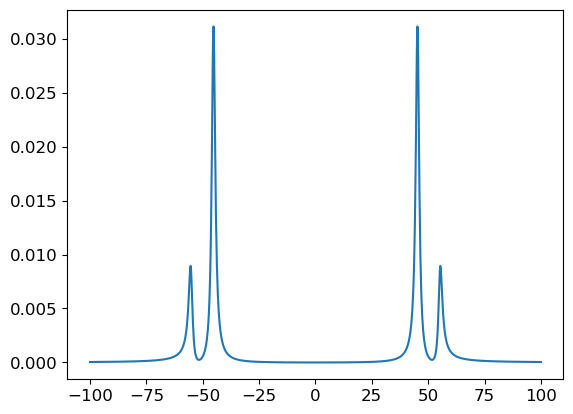

In [70]:
plt.plot(δL, inv_Ts)

Now I believe that for calculating the transmission spectrum using our approach, we should be able to replace $E_{ui}$ with $E_{ui} + \delta_L$.

In [71]:
Ht_eigs[0][1][3]

Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-1.96119584e-01+1.38777878e-17j]
 [ 2.71050543e-18+1.88576390e-04j]
 [ 9.80579968e-01+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]]

In [72]:
# Now generate the new C vectors
new_C = V0 * Ht_eigs[0][1][3]

In [73]:
# Create array for storing transmission spectra
new_Ts = np.zeros(δL.shape[0])
pert_eigs = []
# Calculate transmission spectra
for i in range(δL.shape[0]):
    pert_eigs.append(Ht_eigs[0][1][3] - np.sum([Ht_left_eigs[0][1][j].dag() * V0 * Ht_eigs[0][1][3] / (Ht_eigs[0][0][j] - Ht_eigs[0][0][3] - δL[i]) *
                                         Ht_eigs[0][1][j] for j in range(0,7,2)]))
    new_Ts[i] = (κ / 2) ** 2 * np.abs(new_C.dag() * pert_eigs[i]) ** 2

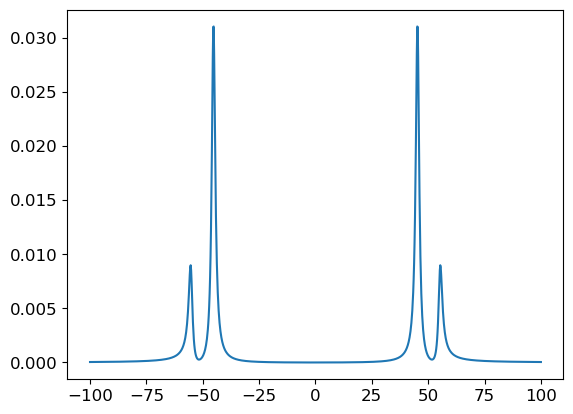

In [74]:
# Plot
plt.plot(δL, new_Ts)

In [75]:
test[500]

Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j]
 [ 1.59898367e-05+1.49401298e-04j]
 [ 3.91957932e-03+6.03523598e-07j]
 [-4.08319582e-05-7.86342099e-07j]
 [-2.03955812e-02-9.40488630e-07j]]

In [76]:
pert_eigs[500]

Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
Qobj data =
[[-1.96119584e-01+1.38777878e-17j]
 [ 2.71050543e-18+1.88576390e-04j]
 [ 9.80579968e-01+0.00000000e+00j]
 [ 1.58489313e-05+4.51435581e-04j]
 [ 3.90055894e-03+1.20551422e-06j]
 [-4.04353297e-05-1.65242121e-03j]
 [-2.01975310e-02-4.35951524e-06j]]

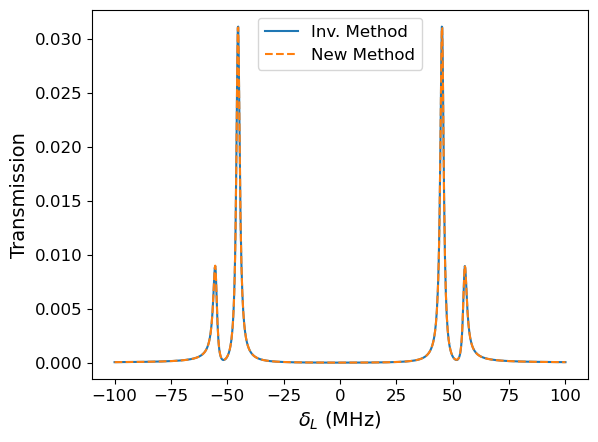

In [77]:
# Now plot together
plt.plot(δL, inv_Ts, label='Inv. Method')
plt.plot(δL, new_Ts, '--', label='New Method')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()
plt.savefig("1_atom_transmission_test.png", format='png', dpi=300)

#### 2 Atom Test

In [78]:
Ht_eigs[1][1]

array([Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.        +0.j        ]
        [ 0.        +0.j        ]
        [ 0.        +0.j        ]
        [ 0.01132272+0.00013895j]
        [-0.04952261-0.00050742j]
        [ 0.70865697+0.j        ]
        [-0.70368608+0.00708743j]]                                           ,
       Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.03238353+0.00032215j]
        [-0.10973962-0.00113146j]
        [ 0.993432  +0.j        ]
        [ 0.        +0.j        ]
        [ 0.        +0.j        ]
        [ 0.        +0.j        ]
        [ 0.        +0.j        ]]                                           ,
       Quantum object: dims=[[7], [1]], shape=(7, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.        +0.j        ]
        [ 0.        +0.j        ]
        [ 0.        +0.j        ]
        [ 0.08178707+0.00283501j]
       

In [79]:
# First pick two of the eigenstates from Hu0 and Hu1 to use
C = V * qu.tensor(Ht_eigs[0][1][3], Ht_eigs[1][1][1])

In [80]:
# Define array for transmission spectrum
inv_Ts = np.zeros(δL.shape[0], dtype=complex)

# Sweep over δL and calculate transmission
test = []
start = time.time()
for i in range(δL.shape[0]):
    temp = (δL[i] + Ht_eigs[0][0][3] + Ht_eigs[1][0][1]) * qu.qeye([7,7]) - H
    temp_inv = temp.inv()
    test.append(temp_inv * λ * C)
    inv_Ts[i] = (κ / 2) ** 2 * np.abs(C.dag() * temp_inv * C) ** 2
print("Elapsed time: ", time.time() - start)

Elapsed time:  5.891798973083496


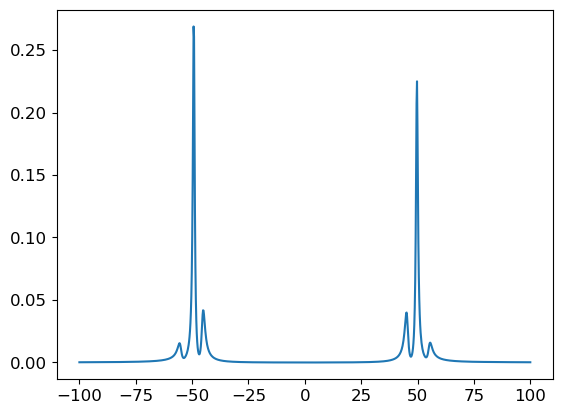

In [81]:
plt.plot(δL, inv_Ts)

In [82]:
# Create array for storing transmission spectra
new_Ts = np.zeros(δL.shape[0])
pert_eigs = []
# Calculate transmission spectra
start = time.time()
for k in range(δL.shape[0]):
    temp = qu.tensor(Ht_eigs[0][1][3], Ht_eigs[1][1][1])
    temp -= np.sum([Ht_left_eigs[0][1][i].dag() * V0 * Ht_eigs[0][1][3] / (Ht_eigs[0][0][i] - Ht_eigs[0][0][3] - δL[k])
                    * qu.tensor(Ht_eigs[0][1][i], Ht_eigs[1][1][1]) for i in range(0,7,2)])
    temp -= np.sum([Ht_left_eigs[1][1][j].dag() * V0 * Ht_eigs[1][1][1] / (Ht_eigs[1][0][j] - Ht_eigs[1][0][1] - δL[k]) 
                    * qu.tensor(Ht_eigs[0][1][3], Ht_eigs[1][1][j]) for j in range(0,7,2)])
    pert_eigs.append(temp)
    new_Ts[k] = (κ / 2) ** 2 * np.abs(C.dag() * pert_eigs[k]) ** 2
print("Elapsed time: ", time.time() - start)

Elapsed time:  0.4983539581298828


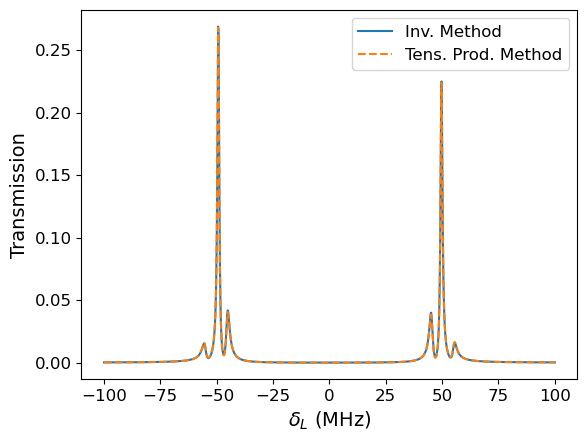

In [83]:
# Now plot together
plt.plot(δL, inv_Ts, label='Inv. Method')
plt.plot(δL, new_Ts, '--', label='Tens. Prod. Method')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()
plt.savefig("2_atom_transmission_v=0,50.png", format='png', dpi=300)

In [84]:
# Just want to check something
C_A = V0 * Ht_eigs[0][1][3]
C_B = V0 * Ht_eigs[1][1][1]

In [85]:
# Define array for transmission spectrum
inv_Ts_A = np.zeros(δL.shape[0], dtype=complex)
inv_Ts_B = np.zeros(δL.shape[0], dtype=complex)

# Sweep over δL and calculate transmission
test = []
for i in range(δL.shape[0]):
    temp = (δL[i] + Ht_eigs[0][0][3]) * qu.qeye(7) - Hts[0]
    temp_inv = temp.inv()
    inv_Ts_A[i] = (κ / 2) ** 2 * np.abs(C_A.dag() * temp_inv * C_A) ** 2

    temp_b = (δL[i] + Ht_eigs[1][0][1]) * qu.qeye(7) - Hts[1]
    temp_b_inv = temp_b.inv()
    inv_Ts_B[i] = (κ / 2) ** 2 * np.abs(C_B.dag() * temp_b_inv * C_B) ** 2

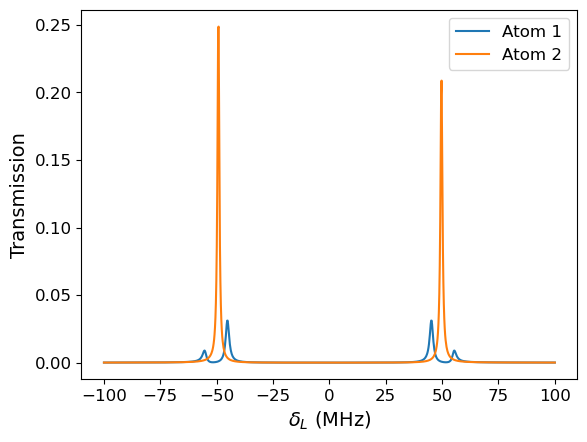

In [86]:
plt.plot(δL, inv_Ts_A, label='Atom 1')
plt.plot(δL, inv_Ts_B, label='Atom 2')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()

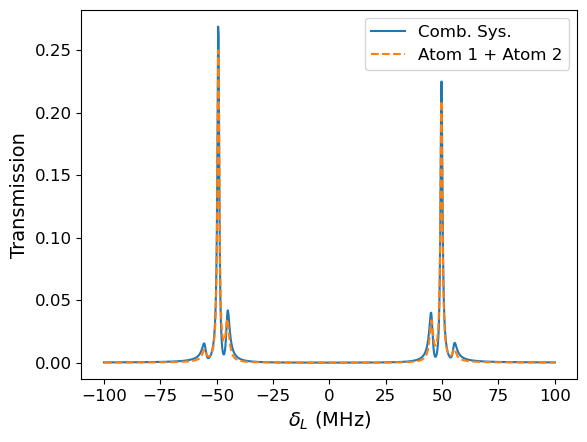

In [87]:
plt.plot(δL, inv_Ts, label='Comb. Sys.')
plt.plot(δL, inv_Ts_A + inv_Ts_B, '--', label='Atom 1 + Atom 2')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()

#### Check the scaling of the splitting
We want to make sure that this model captures the collective effects of the atoms interacting with the cavity.  We can most easily do this by using the inverse method for two identical atoms and compare it to the results for the single atom.

In [88]:
# Define velocity classes
vels = np.array([0, 0])

# Calculate detunings
f01 = 385e6  # MHz
f02 = 625e6  # MHz
Δ1s = f01 / 3e8 * vels
Δ2s = f02 / 3e8 * vels

In [89]:
# Define parameters
g10 = 50
g21 = 10
g32 = 50
κ = 1
γ1 = 1
γ2 = 0.05
γ3 = 0.05

In [90]:
# Define H_u and H_p
Hus = [np.array([[0, g10, 0],
              [g10, -Δ1s[i]-1j*γ1, g21],
              [0, g21, -Δ1s[i]-Δ2s[i]-1j*γ2]])
       for i in range(2)]
Hps = [np.array([[-1j*κ, g10, 0, 0],
              [g10, -Δ1s[i]-1j*κ -1j*γ1, g21, 0],
              [0, g21, -Δ1s[i]-Δ2s[i]-1j*κ-1j*γ2, g32],
              [0, 0, g32, -Δ1s[i]-Δ2s[i]-1j*γ3]])
      for i in range(2)]

In [91]:
# Get Ht from the direct sum
Hts = [linalg.block_diag(Hus[i], Hps[i]) for i in range(2)]

In [92]:
# Turn all the matrices into Qobj for ease of use
Hus = [qu.Qobj(_) for _ in Hus]
Hps = [qu.Qobj(_) for _ in Hps]
Hts = [qu.Qobj(_) for _ in Hts]

In [93]:
# Get the unperturbed eigenstates
Hu_eigs = [_.eigenstates() for _ in Hus]
Hp_eigs = [_.eigenstates() for _ in Hps]
Ht_eigs = [_.eigenstates() for _ in Hts]

In [94]:
# Get the left eigenstates
Hu_left_eigs = [_.dag().eigenstates() for _ in Hus]
Hp_left_eigs = [_.dag().eigenstates() for _ in Hps]
Ht_left_eigs = [_.dag().eigenstates() for _ in Hts]

In [95]:
# Create the V matrix
V = np.zeros((7,7), dtype=complex)
V[0][3] = 1
V[1][4] = 1
V[2][5] = 1
V[3][0] = 1
V[4][1] = 1
V[5][2] = 1
V0 = qu.Qobj(V)

In [96]:
# Calculate the total Hamiltonian
H = qu.tensor(Hts[0], qu.qeye(7)) + qu.tensor(qu.qeye(7), Hts[1])

In [97]:
# Calculate the total V
V = qu.tensor(V0, qu.qeye(7)) + qu.tensor(qu.qeye(7), V0)

In [98]:
# Calculate the single atom C vector for the dark state
C1 = V0 * Ht_eigs[0][1][3]

# Calculate the two atom C vector for the tensor product of the two dark states
C2 = V * qu.tensor(Ht_eigs[0][1][3], Ht_eigs[1][1][3])

In [99]:
# Define δL
δL = np.linspace(-100, 100, 1000)

In [100]:
# Define arrays for transmission spectrums
two_atom_Ts = np.zeros(δL.shape[0], dtype=complex)
one_atom_Ts = np.zeros(δL.shape[0], dtype=complex)
test = np.zeros(δL.shape[0], dtype=complex)

# Sweep over δL and calculate transmission

for i in range(δL.shape[0]):
    temp2 = (δL[i] + Ht_eigs[0][0][3] + Ht_eigs[1][0][3]) * qu.qeye([7,7]) - H
    temp2_inv = temp2.inv()
    two_atom_Ts[i] = (κ / 2) ** 2 * np.abs(C2.dag() * temp2_inv * C2) ** 2

    temp1 = (δL[i] + Ht_eigs[0][0][3]) * qu.qeye(7) - Hts[0]
    temp1_inv = temp1.inv()
    one_atom_Ts[i] = (κ / 2) ** 2 * np.abs(C1.dag() * temp1_inv * C1) ** 2
    test[i] = (κ / 2) ** 2 * np.abs(C1.dag() * temp1_inv * C1 + C1.dag() * temp1_inv * C1) ** 2

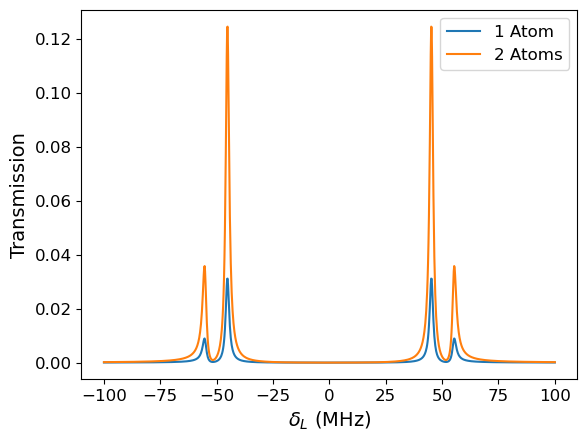

In [101]:
plt.plot(δL, one_atom_Ts, label='1 Atom')
plt.plot(δL, two_atom_Ts, label='2 Atoms')
#plt.plot(δL, test, 'k--')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()

In [102]:
# Check 4 level eigenvalues against solutions for zero detuning
λ1 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ0 = -λ1
λ3 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 + 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ2 = -λ3

print("Hp eigs: ", Hp_eigs[0][0])
print("\nλ0: ", λ0)
print("λ1: ", λ1)
print("λ2: ", λ2)
print("λ3: ", λ3)

Hp eigs:  [-55.2245079 -1.07497807j -45.26927736-0.97502193j
  45.26927736-0.97502193j  55.2245079 -1.07497807j]

λ0:  -45.24937810560445
λ1:  45.24937810560445
λ2:  -55.24937810560445
λ3:  55.24937810560445


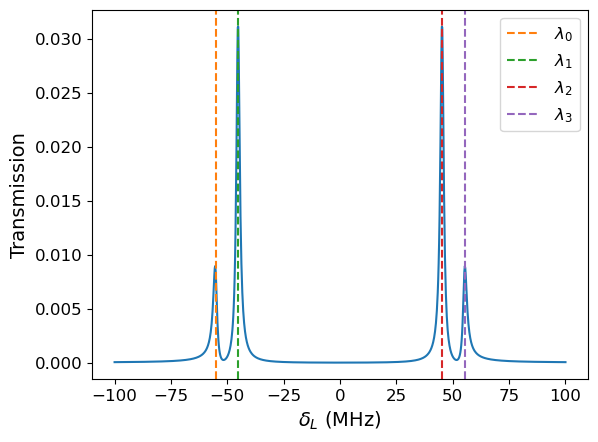

In [103]:
colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple']
plt.plot(δL, one_atom_Ts)
for i in range(4):
    plt.axvline(x=Hp_eigs[0][0][i], color=colors[i], linestyle='--', label='$\\lambda_'+str(i)+'$')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()

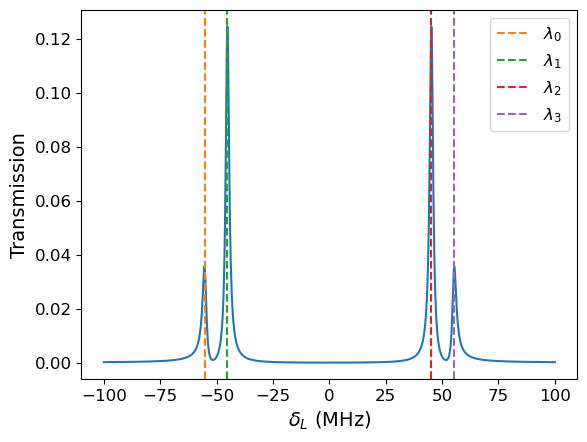

In [104]:
plt.plot(δL, two_atom_Ts)
for i in range(4):
    plt.axvline(x=Hp_eigs[0][0][i], color=colors[i], linestyle='--', label='$\\lambda_'+str(i)+'$')
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.legend()

What do the eigenvalues look like for the two atom system compared to the single atom one as the detuning changes?

In [105]:
# Define the detuning values
δL = np.linspace(-100, 100, 1000)

In [106]:
# Get eigenvalues at zero detuning for comparison
Hu = np.array([[0, g10, 0],
               [g10, -1j*γ1, g21],
               [0, g21, -1j*γ2]])
Hp = np.array([[-1j*κ, g10, 0, 0],
               [g10, -1j*κ -1j*γ1, g21, 0],
               [0, g21, -1j*κ -1j*γ2, g32],
               [0, 0, g32, -1j*γ3]])
H_sa = linalg.block_diag(Hu, Hp)
H_sa = qu.Qobj(H_sa)
sa_zero_det_eigs = H_sa.eigenstates()[0]

H_da = qu.tensor(H_sa, qu.qeye(7)) + qu.tensor(qu.qeye(7), H_sa)
da_zero_det_eigs = H_da.eigenstates()[0]

In [107]:
# print zero detuning eigenvalues
print("Single atom eigs: ", sa_zero_det_eigs)
print("Double atom eigs: ", da_zero_det_eigs)

Single atom eigs:  [-5.52245079e+01-1.07497807j -5.09877521e+01-0.50096156j
 -4.52692774e+01-0.97502193j -1.32569496e-16-0.04807689j
  4.52692774e+01-0.97502193j  5.09877521e+01-0.50096156j
  5.52245079e+01-1.07497807j]
Double atom eigs:  [-1.10449016e+02-2.14995614j -1.06212260e+02-1.57593962j
 -1.06212260e+02-1.57593962j -1.01975504e+02-1.00192311j
 -1.00493785e+02-2.05j       -1.00493785e+02-2.05j
 -9.62570295e+01-1.47598349j -9.62570295e+01-1.47598349j
 -9.05385547e+01-1.95004386j -5.52245079e+01-1.12305496j
 -5.52245079e+01-1.12305496j -5.09877521e+01-0.54903844j
 -5.09877521e+01-0.54903844j -4.52692774e+01-1.02309882j
 -4.52692774e+01-1.02309882j -9.95523055e+00-2.05j
 -9.95523055e+00-2.05j       -5.71847478e+00-1.47598349j
 -5.71847478e+00-1.47598349j -4.23675576e+00-1.57593962j
 -4.23675576e+00-1.57593962j -3.79714098e-15-2.14995614j
 -2.94902991e-17-1.95004386j -1.56701095e-18-1.00192311j
  2.22044605e-16-1.95004386j  2.31893974e-15-2.14995614j
  1.29181734e-14-1.00192311j  3.

In [108]:
# Create array for storing eigenvalues
sa_eig_vals = np.zeros((δL.shape[0], 7), dtype=complex)
da_eig_vals = np.zeros((δL.shape[0], 7**2), dtype=complex)

# Calculate the eigenvalues of the single and double atom Hamiltonians as the detuning changes
for i in range(δL.shape[0]):
    Hu = np.array([[0, g10, 0],
                   [g10, δL[i]-1j*γ1, g21],
                   [0, g21, δL[i]-1j*γ2]])
    Hp = np.array([[-1j*κ, g10, 0, 0],
                   [g10, -1j*κ -1j*γ1, g21, 0],
                   [0, g21, -1j*κ -1j*γ2, g32],
                   [0, 0, g32, -1j*γ3]])
    H_sa = linalg.block_diag(Hu, Hp)
    H_sa = qu.Qobj(H_sa)
    sa_eig_vals[i] = H_sa.eigenstates()[0]

    H_da = qu.tensor(H_sa, qu.qeye(7)) + qu.tensor(qu.qeye(7), H_sa)
    da_eig_vals[i] = H_da.eigenstates()[0]

Text(0, 0.5, 'Eigenvalue')

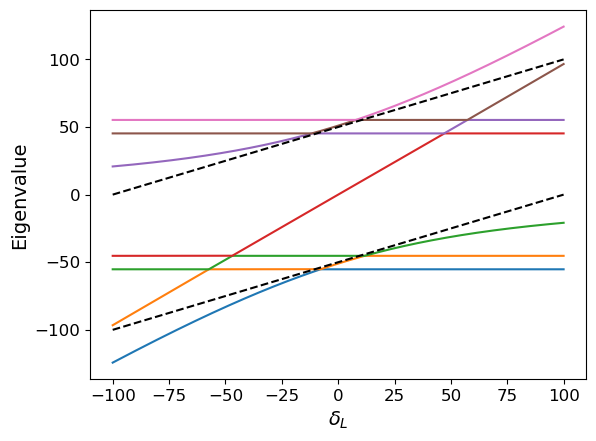

In [109]:
for i in range(7):
    plt.plot(δL, sa_eig_vals.T[i])
plt.plot(δL, 0.5*δL+g32, 'k--')
plt.plot(δL, 0.5*δL-g32, 'k--')
plt.xlabel("$\\delta_L$")
plt.ylabel("Eigenvalue")

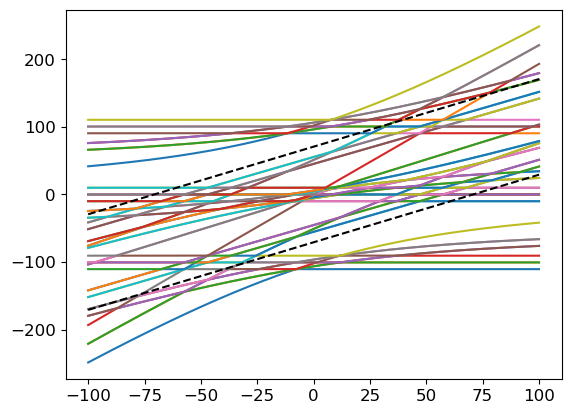

In [110]:
for i in range(7**2):
    plt.plot(δL, da_eig_vals.T[i])
plt.plot(δL, δL+np.sqrt(2)*g32, 'k--')
plt.plot(δL, δL-np.sqrt(2)*g32, 'k--')

Ok, so it doesn't look like the second atom is changing the splitting of the eigenvalues to something like $\sqrt{2}g_{32}$, which is what we would hope to see.  Instead, it looks like we just have different eigenvalues that are split by $2g_{32}$.  What if we consider a Hamiltonian that looks more like the Tavis-Cummings model?  Let's check that by incorporating the cavity field and the two four level atoms fully.  We'll consider a two level Fock state to represent the cavity mode.

What if we adiabatically eliminated the intermediate states to end up with an effective two level system?  We can add in $\delta_c$ and set it to be $-(\Delta_1 + \Delta_2)$.  We would want the $\Delta$s to be larger than the damping rates, and have an effective Rabi frequency that is larger than the Rydberg damping rate as well.